In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('ice_cream_sales.csv')
df.head()

,temperature_c,day_type,ice_cream_sales
0,5.0,Weekday,12
1,5.9,Weekday,33
2,6.4,Weekday,42
3,6.9,Weekend,126
4,7.3,Weekday,27


# Predict

In [3]:
X = df[['temperature_c']]
y = df['ice_cream_sales']

X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2, shuffle=True, random_state=42)

In [4]:
# Fit
model = LinearRegression()
model.fit(X_train,y_train)

# 3. Make predictions on new data
predictions = model.predict(X_test)

r2_score(y_test, predictions) #88%

0.8836980629283266

## Plot

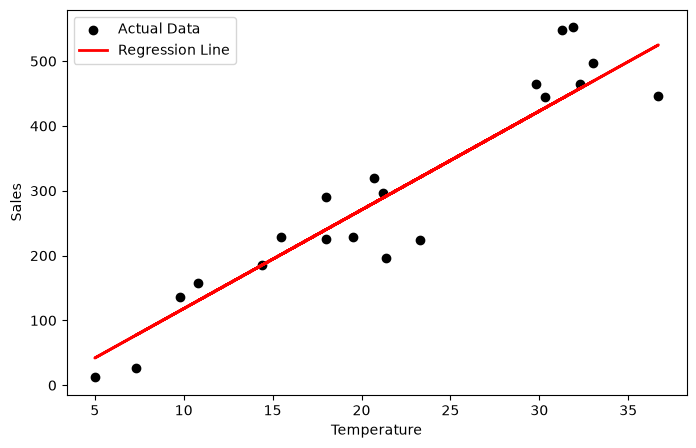

In [5]:
plt.figure(figsize=(8, 5))

# 1. Plot the actual test data points
plt.scatter(X_test, y_test, color='black', label='Actual Data')

# 2. Plot the regression line using your predictions
plt.plot(X_test, predictions, color='red', linewidth=2, label='Regression Line')

# 3. Label the plot
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()

In [6]:
# adding second feature
df = pd.get_dummies(df, columns=['day_type'], drop_first=True, dtype=int)
df.head(10)

,temperature_c,ice_cream_sales,day_type_Weekend
0,5.0,12,0
1,5.9,33,0
2,6.4,42,0
3,6.9,126,1
4,7.3,27,0
5,7.5,83,1
6,7.7,3,0
7,8.2,97,0
8,9.6,64,0
9,9.7,111,0


In [7]:
X2 = df[['temperature_c','day_type_Weekend']]
y = df['ice_cream_sales']

X2_train, X2_test, y_train, y_test = train_test_split(X2,y , test_size=0.2, shuffle=True, random_state=42)

In [8]:
# Fit
model = LinearRegression()
model.fit(X2_train,y_train)

# 3. Make predictions on new data
predictions = model.predict(X2_test)

r2_score(y_test, predictions) #93.5%

0.9354220505060598